# Exercise 1 - Smoothing and Interpolation

## Introduction
text here

### Install & Import Libraries

In [1]:
!pip3 install numpy nibabel matplotlib

In [2]:
import numpy as np
import nibabel as nib
from matplotlib import pyplot as plt

np.set_printoptions( suppress=True )
plt.style.use('dark_background') # Dark theme
plt.ion()

Read a 3D image (an MRI scan of the brain) and extract the 2D slice you'll be working with in this exercise:

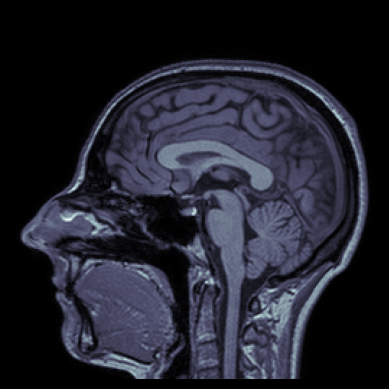

In [3]:
T1_file = './IXI002-Guys-0828-T1.nii.gz'
T1_nib = nib.load( T1_file )
data = T1_nib.get_fdata()

img = data[:, :, 75]
T = np.flipud( img.T )

plt.axis('off')
plt.imshow(T, cmap='bone');

Extract the 1D signal you'll be working with as the middle row of the 2D image

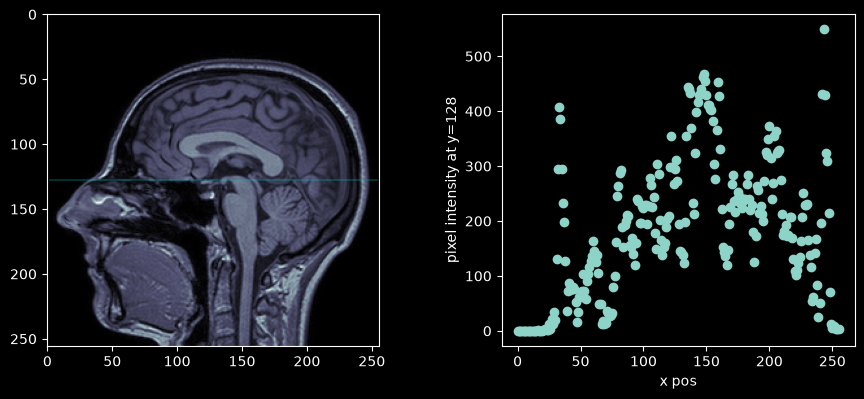

In [4]:
row = round( T.shape[0] / 2 )
t = T[row, :] #pixel intensity at row y = 128

N = t.shape[0]
x = np.arange(0, N)

# plot
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(10,5))
fig.tight_layout(pad=5.0)

ax[0].imshow(T, cmap='bone')
ax[0].hlines(row, xmin=1, xmax=255, alpha=0.25, color='c')

ax[1].scatter(x, t)
ax[1].set_xlabel('x pos')
ax[1].set_ylabel('pixel intensity at y={}'.format(row))

plt.show();

---
## Task 1: B-splines basis functions
In this task, we implement a function that evaluates the uniform B-spline of orders 0, 1 and 3 at the locations provided in a vector $\mathbf{x}$. The equations for these B-spline basis functions are given by the following identities, as given in the lecture notes:

$$
\beta^0(x) =
\begin{cases}
1, & -\tfrac{1}{2} < x < \tfrac{1}{2} \\
\tfrac{1}{2}, & |x| = \tfrac{1}{2} \\
0, & \text{otherwise}
\end{cases}
$$

$$
\beta^1(x) =
\begin{cases}
1 - |x|, & |x| < 1 \\
0, & \text{otherwise}
\end{cases}
$$

$$
\beta^3(x) =
\begin{cases}
\dfrac{2}{3} - |x|^2 + \dfrac{|x|^3}{2}, & |x| < 1 \\[6pt]
\dfrac{(2-|x|)^3}{6}, & 1 \le |x| < 2 \\[6pt]
0, & \text{otherwise}
\end{cases}
$$

The function returns a vector $\mathbf{y}$ that is the same length as $\mathbf{x}$. We then plot the uniform B-spline of orders 0, 1 and 3 at locations:  $\mathbf{x} = [-3.0,-2.99,-2.98, \ldots, 2.99,3.0]$.


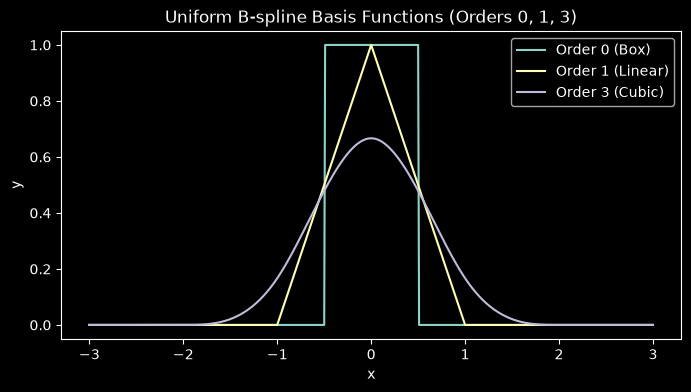

In [5]:
def eval_BSpline(x, order=0):
    """
    Evaluates the uniform B-spline of order "order" at the locations in vector "x".
    Supports orders 0, 1, and 3.
    """
    x = np.asarray(x, dtype=float)
    abs_x = np.abs(x)
    y = np.zeros_like(x)

    if order == 0:
        inside_mask = abs_x < 0.5
        edge_mask = abs_x == 0.5

        y[inside_mask] = 1.0
        y[edge_mask] = 0.5

    elif order == 1:
        mask = abs_x < 1.0

        y[mask] = 1.0 - abs_x[mask]

    elif order == 3:
        inner_mask = abs_x < 1.0
        outer_mask = (abs_x >= 1.0) & (abs_x < 2.0)

        x_inner = abs_x[inner_mask]
        squared_term = x_inner ** 2
        cubed_term = x_inner ** 3
        y[inner_mask] = 2/3 - squared_term + 0.5 * cubed_term

        x_outer = abs_x[outer_mask]
        base = 2 - x_outer
        y[outer_mask] = (base ** 3) / 6

    return y

x = np.arange(-3.0, 3.0 + 0.005, 0.01)

y0 = eval_BSpline(x, order=0)
y1 = eval_BSpline(x, order=1)
y3 = eval_BSpline(x, order=3)

plt.figure(figsize=(8, 4))
plt.plot(x, y0, label="Order 0 (Box)")
plt.plot(x, y1, label="Order 1 (Linear)")
plt.plot(x, y3, label="Order 3 (Cubic)",)

plt.title("Uniform B-spline Basis Functions (Orders 0, 1, 3)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

The figure above illustrates the uniform B-spline functions for orders 0, 1, and 3.

---
## Task 2: Smoothing
Using the function we wrote above for evaluating a uniform B-spline of order 3, we generate $M=6$ basis functions covering the entire domain $x=0,1,\ldots, 255$ of the 1D signal $\mathbf{t}$ defined in the introduction (which has length $N=256$). 

The basis functions is be scaled by a factor $h=(N-1)/(M-1)$, and shifted to be $h$ units apart. More specifically, we shift by $h$ in order to cover the full range of $x$ from one end to the other, and then we scale by $h$ to "stretch" the basis functions in the appropriate $x$ units. As a results, the basis functions will be given by:

$$\varphi_m(x) = \beta^p\left( \frac{x - mh}{h} \right).$$

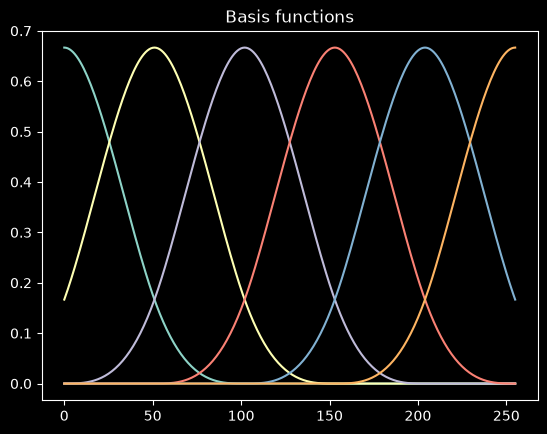

In [6]:
N = 256
M = 6

x = np.arange(N)
h = (N - 1) / (M - 1) # scaling factor

Phi = np.zeros((N, M))

for m in range(M):
    center = m * h
    Phi[:, m] = eval_BSpline((x - center) / h, order=3)

plt.plot(x, Phi)
plt.title("Basis functions")
plt.show()

We can then calculate the smoothing matrix using the following identity:
$$\mathbf{S} = \boldsymbol{\Phi} (\boldsymbol{\Phi}^T \boldsymbol{\Phi})^{-1} \boldsymbol{\Phi}^T.$$

In addition, the smoothed signal is given by:
$$\mathbf{\hat{t}} = \mathbf{S} \mathbf{t}.$$

In [7]:
S = Phi @ np.linalg.inv((np.transpose(Phi)) @ Phi) @ np.transpose(Phi)

In [8]:
t_smooth= S @ t

### Left figure (below)
In the figure on the left, the smoothing matrix $S$ is represented visually. Essentially, the brightness of pixel $(i, j)$ corresponds to the $S_{ij}$ entry of the smoothing matrix, or how much sample $j$ from the original signal contributes to the smoothed value at position $i$. The bright diagnonal band forms because $S_{ij}$ is higher when $i$ and $j$ are closer together, or when the basis functions closer to each other. This illustrates the idea that the smoothed version uses mostly local neighbours.

In addition, the 6 dark "blobs" along the bright diagonal correspond to the $M=6$ basis functions. This "oscillation" along the edges of the bright diagonal happen because the basis functions overlap their neighnours when spanning the whole domain. Another important feature to point out is the thickness of the diagonal band: because we have a relatively low number of basis functions here, the band becomes wider because, again, the basis functions overlap each other.

### Right figure (below)
The figure on the right compares the original signal (blue) to the smoothed out signal (red). Because we have a lower number of basis functions ($M=6$), the curve in red only captures the general trend of the original signal.

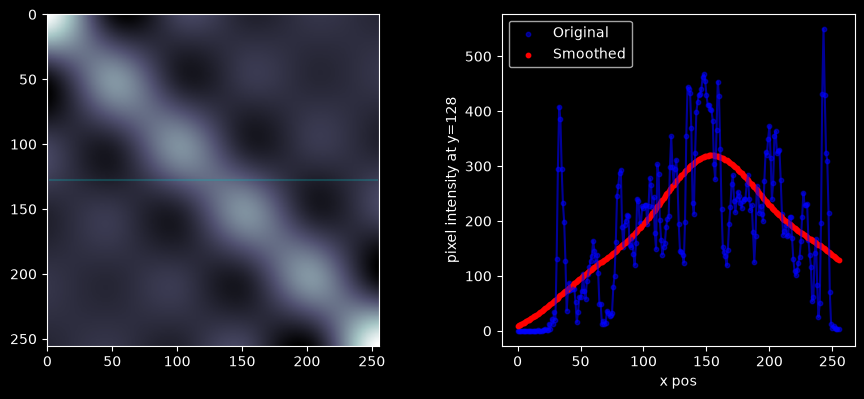

In [9]:
row = round(T.shape[0] / 2)
t = T[row, :]

N = t.shape[0]
x = np.arange(0, N)

# plot
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
fig.tight_layout(pad=5.0)

ax[0].imshow(S, cmap="bone")
ax[0].hlines(row, xmin=1, xmax=255, alpha=0.25, color="c")

ax[1].plot(x, t, color="blue", alpha=0.6)
ax[1].scatter(x, t, label='Original', color='blue', s=10, alpha=0.5)

ax[1].scatter(x, t_smooth, label="Smoothed", color="red", s=10)

ax[1].set_xlabel("x pos")
ax[1].set_ylabel("pixel intensity at y={}".format(row))
ax[1].legend()

plt.show()

We then repeat the experiments using $M=16$ and $M=52$.

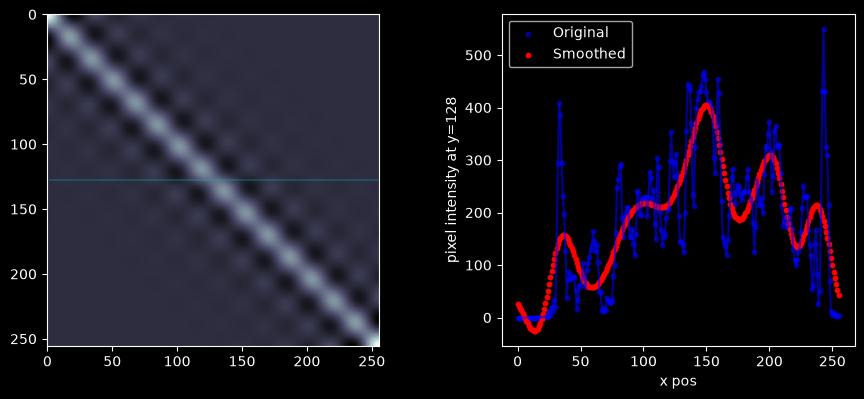

In [10]:
# repeat calculations with M=16
N = 256
M = 16

x = np.arange(N)
h = (N - 1) / (M - 1)

Phi = np.zeros((N, M))

for m in range(M):
    center = m * h
    Phi[:, m] = eval_BSpline((x - center) / h, order=3)

S = Phi @ np.linalg.inv((np.transpose(Phi)) @ Phi) @ np.transpose(Phi)
t_smooth= S @ t

row = round(T.shape[0] / 2)
t = T[row, :]

N = t.shape[0]
x = np.arange(0, N)

# plot
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
fig.tight_layout(pad=5.0)

ax[0].imshow(S, cmap="bone")
ax[0].hlines(row, xmin=1, xmax=255, alpha=0.25, color="c")

ax[1].plot(x, t, color="blue", alpha=0.6)
ax[1].scatter(x, t, label='Original', color='blue', s=10, alpha=0.5)

ax[1].scatter(x, t_smooth, label="Smoothed", color="red", s=10)

ax[1].set_xlabel("x pos")
ax[1].set_ylabel("pixel intensity at y={}".format(row))
ax[1].legend()

plt.show()


When increasing the number of basis functions to $M=16$, we can observe in the figure on the left that the bright band becomes narrower, with more dark "blobs"/oscillations next to it. In this situation, two points have to be much closer together to both land inside the same basis function. In addition, we can also observe a shadow-like feature, parallel to the bright diagonal. This happens because this time the basis functions don't only overlap with their immediate neighbours, but also with more distant ones as well.

In the right figure, we can see that increasing the number of basis functions makes the smoothed out signal to follow the original signal more closely.

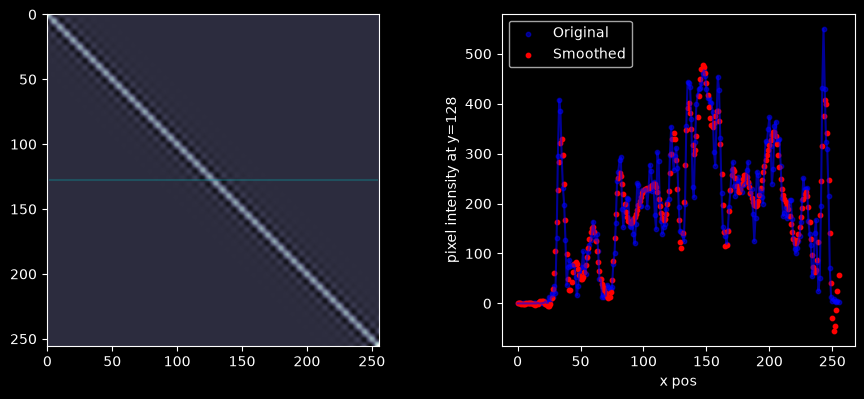

In [11]:
# repeat calculations with M=52
N = 256
M = 52

x = np.arange(N)
h = (N - 1) / (M - 1)

Phi = np.zeros((N, M))

for m in range(M):
    center = m * h
    Phi[:, m] = eval_BSpline((x - center) / h, order=3)

S = Phi @ np.linalg.inv((np.transpose(Phi)) @ Phi) @ np.transpose(Phi)
t_smooth= S @ t

row = round(T.shape[0] / 2)
t = T[row, :]

N = t.shape[0]
x = np.arange(0, N)

# plot
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
fig.tight_layout(pad=5.0)

ax[0].imshow(S, cmap="bone")
ax[0].hlines(row, xmin=1, xmax=255, alpha=0.25, color="c")

ax[1].plot(x, t, color="blue", alpha=0.6)
ax[1].scatter(x, t, label='Original', color='blue', s=10, alpha=0.5)

ax[1].scatter(x, t_smooth, label="Smoothed", color="red", s=10)

ax[1].set_xlabel("x pos")
ax[1].set_ylabel("pixel intensity at y={}".format(row))
ax[1].legend()

plt.show()


In the left figure, when increasing to $M=52$, the bright diagonal becomes even narrower, as basis functions become even narrower. In addition, the wavy pattern lining the bright diagonal has an even higher frequency. Finally, we can observe in the right figure that the smoothed out signal follows the original signal even more closely, as compared to the previous two situations.

---
## Task 3: Interpolation
We then implement B-spline interpolation of the 1D signal $\mathbf{t}$, by evaluating the function $y( x, \mathbf{w})$ at locations $x = [120, 120.01, 120.02, \ldots 140]$

In the 3 figures below, we can observe the original signal and three different orders of B-splines: 0, 1 and 3. It can be noticed that a higher order gives smoother interpolation curves.

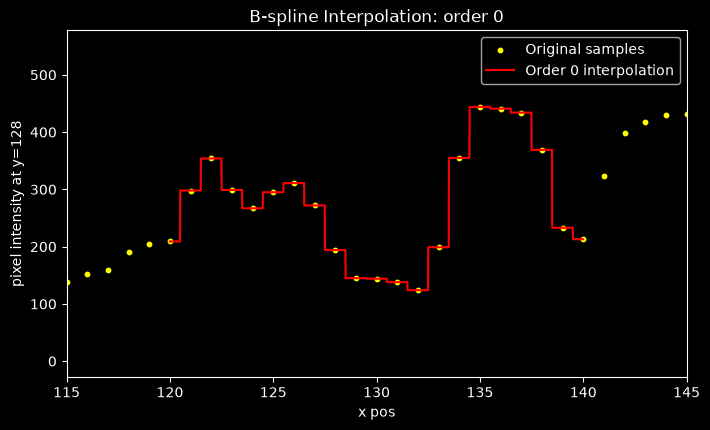

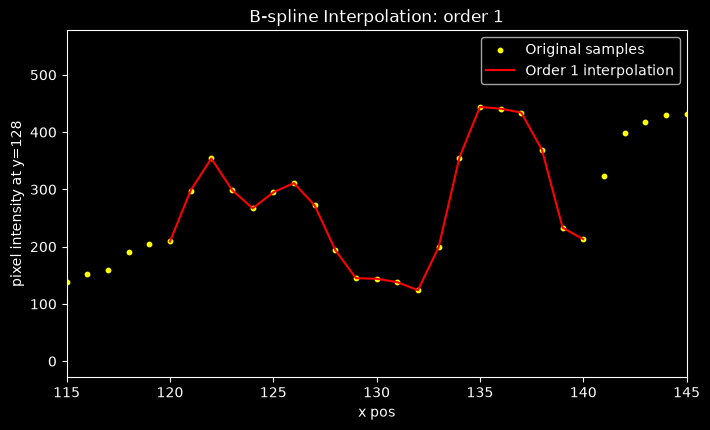

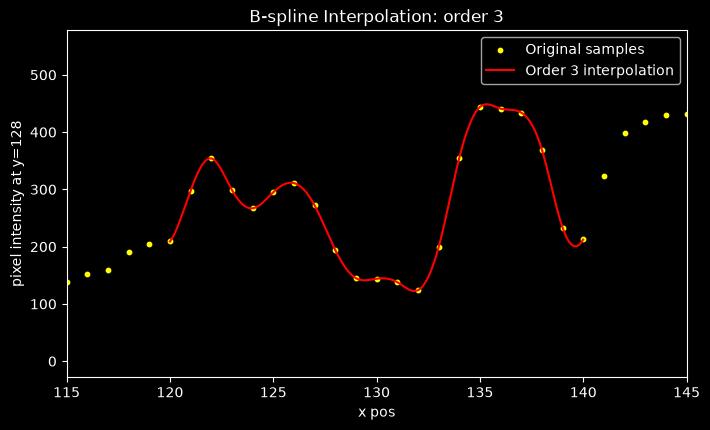

In [12]:
row = round(T.shape[0] / 2)
t = T[row, :]
N = t.shape[0]
x = np.arange(N)
xq = np.arange(120, 140, 0.01)

for order in [0, 1, 3]:
    Phi = np.zeros((N, N))
    for m in range(N):
        Phi[:, m] = eval_BSpline(x - m, order=order)
    w = np.linalg.solve(Phi, t)

    Phi_q = np.zeros((len(xq), N))
    for m in range(N):
        Phi_q[:, m] = eval_BSpline(xq - m, order=order)
    y = Phi_q @ w

    #plot
    plt.figure(figsize=(8, 4.5))
    plt.scatter(x, t, label="Original samples", color="yellow", s=10, alpha=1)
    plt.plot(xq, y, label=f"Order {order} interpolation", color="red")
    plt.xlim(115, 145)
    plt.xlabel("x pos")
    plt.ylabel(f"pixel intensity at y={row}")
    plt.title(f"B-spline Interpolation: order {order}")
    plt.legend()
    plt.show()

---
## Task 4: Smoothing in 2D
Now you are going to smooth the 2D image $\mathbf{T}$, which has dimensions $N_1 \times N_2 = 256 \times 256$, with $M_1=M_2=5$ B-spline-based 1D basis functions of order 3 for each direction.

Use the Kronecker product to produce a $N \times M$ matrix $\boldsymbol{\Phi} = \boldsymbol{\Phi}_2 \otimes \boldsymbol{\Phi}_1$, where:
- $N=N_1 N_2$ 
- $M = M_1 M_2$. 

Show a few 2D basis functions contained in the columns of $\boldsymbol{\Phi}$.

>***Hints***:
>* the Kronecker product of two matrices A and B can be calculated with ```np.kron(A, B)```
>* for converting a vectorized basis function ```v``` back into its 2D shape, use ```v.reshape(N_1, N_2, order='F')```
>* the following snippet can be used to show a 2D basis function:
>    ```
>        plt.figure(); 
>        ax = plt.axes(projection='3d'); 
>        ax.plot_wireframe(np.arange(N1).reshape(-1, 1), np.arange(N2).reshape(1, -1), basisFunction)
>
>    ```

Now:
- vectorize the 2D image $\mathbf{T}$ into a 1D signal $\mathbf{t}$
- smooth using $\boldsymbol{\Phi}$
- re-arrange the resulting 1D signal $\mathbf{\hat{t}}$ back into a 2D image $\mathbf{\hat{T}}$
- show the result.

>***Hints***: 
>* use ```T.reshape(-1, 1, order='F')``` and ```t.reshape(N_1, N_2, order='F')``` to vectorize and undo the vectorization.
>* do not explicitly compute the smoothing matrix $\mathbf{S}$ as it is very large!! Instead compute the weights $\mathbf{w} = (\boldsymbol{\Phi}^T \boldsymbol{\Phi})^{-1} \boldsymbol{\Phi}^T \mathbf{t}$ and expand those to get $\mathbf{\hat{t}} = \boldsymbol{\Phi} \mathbf{w}$.


Also perform the same smoothing operation by exploiting the separability of the 2D basis functions, i.e, perform row-wise and then column-wise smoothing instead. 

Show the results, and verify that they are identical (use ```np.allclose()```) 

---
## Task 5: Interpolation in 2D
For B-spline order 0, 1 and 3, compute the weights $\mathbf{W}$ of the 2D interpolation model fitted to $\mathbf{T}$ by exploiting the separability of its basis functions.

Then show, as an image, interpolated function values $y( \mathbf{x}, \mathbf{w})$ for $\mathbf{x}=(x_1, x_2)^T$ with:
- $x_1=120.0, 120.1, 120.2 \ldots, 130.0$ 
- $x_2=120.0, 120.1, 120.2 \ldots, 130.0$ 

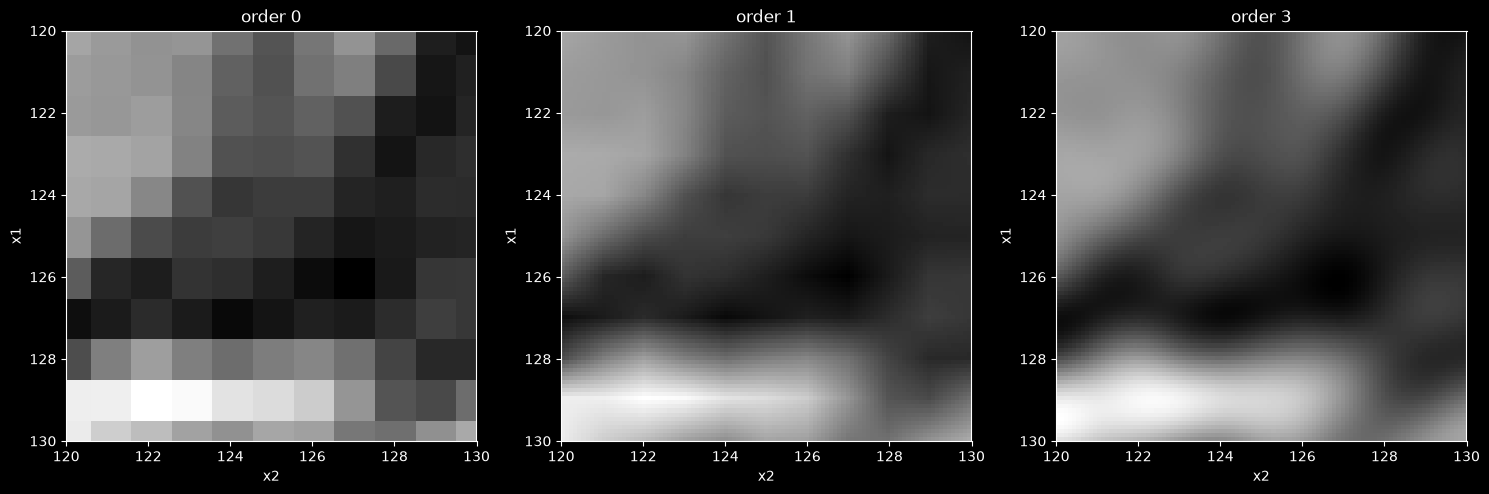

In [ ]:
N1, N2 = 256, 256
M1, M2 = 5, 5

# Builds the design matrix needed for exact interpolation in 1D with  M = N
def build_Phi_1D_interp(N, order):
    
    x = np.arange(N)
    Phi = np.zeros((N, N))
    for m in range(N):
        Phi[:, m] = eval_BSpline(x - m, order=order)
    return Phi

# Fine evaluation grid: 120.0, 120.1, ..., 130.0 
x1_eval = np.arange(120, 130.01, 0.1)
x2_eval = np.arange(120, 130.01, 0.1)

orders = [0, 1, 3]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, order in zip(axes, orders):
    Phi1 = build_Phi_1D_interp(N1, order)
    Phi2 = build_Phi_1D_interp(N2, order)

    # Solve for W by exploiting separability: T = Phi1 @ W @ Phi2^T
    A = np.linalg.solve(Phi1, T)
    W = np.linalg.solve(Phi2, A.T).T

    # Basis matrices evaluated at the fine grid (rectangular, not square)
    Psi1 = eval_BSpline(x1_eval.reshape(-1, 1) - np.arange(N1).reshape(1, -1), order=order)
    Psi2 = eval_BSpline(x2_eval.reshape(-1, 1) - np.arange(N2).reshape(1, -1), order=order)

    Y = Psi1 @ W @ Psi2.T

    ax.imshow(Y, cmap='gray', extent=[120, 130, 130, 120])
    ax.set_title(f"order {order}")
    ax.set_xlabel("x2")
    ax.set_ylabel("x1")

plt.tight_layout()
plt.show()

**Task 5 — 2D interpolation**

We use $M=N$ basis functions per dimension so the model passes exactly through every pixel of $\mathbf{T}$ (interpolation, not smoothing). Since $\mathbf{\Phi}=\mathbf{\Phi}_2\otimes\mathbf{\Phi}_1$, the condition $\mathbf{T}=\mathbf{\Phi}_1\mathbf{W}\mathbf{\Phi}_2^T$ can be solved separably — two $256\times256$ solves for $\mathbf{W}$ instead of one infeasible $65536\times65536$ system.

Once $\mathbf{W}$ is known, $y(\mathbf{x},\mathbf{W})=\sum_{m_1,m_2}W_{m_1,m_2}\phi_{m_1}(x_1)\phi_{m_2}(x_2)$ defines a continuous surface, evaluable at any (non-integer) location — this is what lets us "zoom in" between pixels. Higher B-spline order gives smoother interpolation: order 0 is blocky (nearest neighbor), order 3 is smooth (cubic).

## Conclusion
text here